In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from pathlib import Path
from calculator import SeaIceCalc, Habitability, SST, SRD

In [4]:
file_indices = [1,2,3,4,5,6]
print(file_indices)

gravity = [0.5,0.75,1,1.25,1.5,1.75]
print(gravity)

[1, 2, 3, 4, 5, 6]
[0.5, 0.75, 1, 1.25, 1.5, 1.75]


In [5]:
file_template = "../gravity/output{}.nc"
results = []

In [6]:
for idx in file_indices:
    fname = file_template.format(idx)

    # Ensure file exists
    if not Path(fname).exists():
        print(f"Warning: {fname} not found, skipping.")
        continue

    # Prepare containers for this file/run
    run = {
        "month": [],
        "ice_tot": [], "ice_nhem": [], "ice_shem": [],
        "sm_tot": [],  "sm_nhem": [],  "sm_shem": [],
        "st_tot": [],  "st_nhem": [],  "st_shem": [],
        "tsurf_tot": [], "tsurf_nhem": [], "tsurf_shem": [],
        "sst_tot": [], "sst_nhem": [], "sst_shem": [],
        "srd_tot": [], "srd_nhem": [], "srd_shem": []
    }
    
    # Open dataset and process
    with xr.open_dataset(fname) as ds:
        ds_crop = ds.sel(time=slice("2001-01-01", "2002-01-01"))
        monthly_data = ds_crop.groupby("time.month")
        months = np.array(sorted(monthly_data.groups.keys()), dtype=int)
        run["month"].append(months)

        for month, data in monthly_data:

            # Whole globe
            ice_frac = SeaIceCalc.ice_frac(data)[0]
            fraction_sm = Habitability.fraction(data, "sm")[0]
            fraction_st = Habitability.fraction(data, "st")[0]
            fraction_tsurf = Habitability.fraction(data, "tsurf")[0]
            sst_tot = SST.temp(data)
            srd_tot = SRD.srd_calc(data)[0]


            run["ice_tot"].append(ice_frac)
            run["sm_tot"].append(fraction_sm)
            run["st_tot"].append(fraction_st)
            run["tsurf_tot"].append(fraction_tsurf)
            run["sst_tot"].append(sst_tot)
            run["srd_tot"].append(srd_tot)

            # Northern hemisphere
            ice_n = SeaIceCalc.ice_frac(data, lat=slice(0,24))[0]
            sm_n = Habitability.fraction(data, "sm", lat=slice(0,24))[0]
            st_n = Habitability.fraction(data, "st", lat=slice(0,24))[0]
            tsurf_n = Habitability.fraction(data, "tsurf", lat=slice(0,24))[0]
            sst_n = SST.temp(data, lat=slice(0,24))
            srd_n = SRD.srd_calc(data, lat=slice(0,24))[0]

            run["ice_nhem"].append(ice_n)
            run["sm_nhem"].append(sm_n)
            run["st_nhem"].append(st_n)
            run["tsurf_nhem"].append(tsurf_n)
            run["sst_nhem"].append(sst_n)
            run["srd_nhem"].append(srd_n)

            # Southern hemisphere
            ice_s = SeaIceCalc.ice_frac(data, lat=slice(24,48))[0]
            sm_s = Habitability.fraction(data, "sm", lat=slice(24,48))[0]
            st_s = Habitability.fraction(data, "st", lat=slice(24,48))[0]
            tsurf_s = Habitability.fraction(data, "tsurf", lat=slice(24,48))[0]
            sst_s = SST.temp(data, lat=slice(24,48))
            srd_s = SRD.srd_calc(data, lat=slice(24,48))[0]
            run["ice_shem"].append(ice_s)
            run["sm_shem"].append(sm_s)
            run["st_shem"].append(st_s)
            run["tsurf_shem"].append(tsurf_s)
            run["sst_shem"].append(sst_s)
            run["srd_shem"].append(srd_s)

    # convert lists to numpy arrays (for math/plotting later)
    for k in run:
        if run[k] is None:
            continue
        if isinstance(run[k], list):
            run[k] = np.array(run[k]) 

    # Store results
    results.append({"file": fname, "data": run})


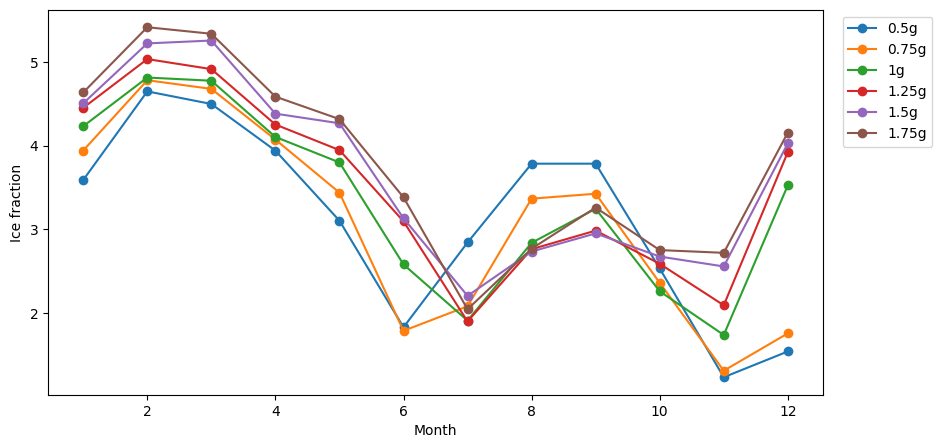

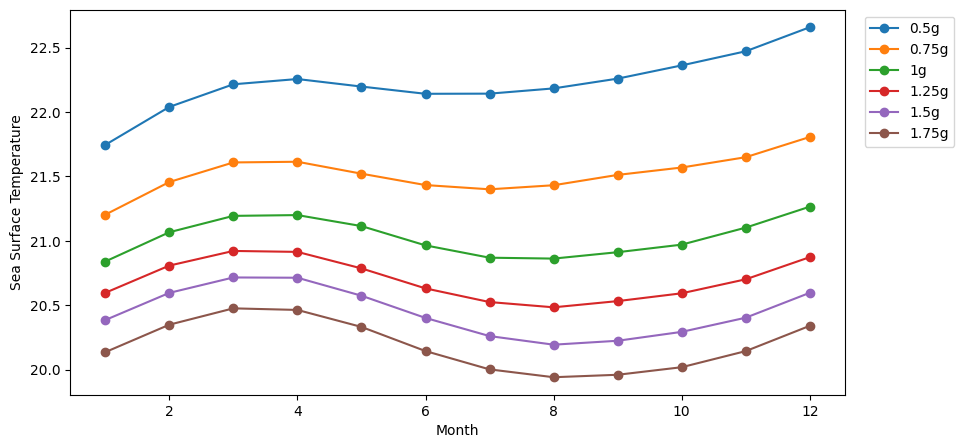

In [7]:
fig = plt.figure(figsize=(10, 5))
for r, grav in zip(results, gravity):
    ice = r["data"]["ice_tot"]
    month = r["data"]["month"][0]
    # plt.plot(month, ice, marker='o', label=f"{axtilt}$^o$")
    plt.plot(month, ice, marker='o', label=f"{grav}g")
plt.xlabel("Month")
plt.ylabel("Ice fraction")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, grav in zip(results, gravity):
    sst = r["data"]["sst_tot"]
    month = r["data"]["month"][0]
    # plt.plot(month, sst, marker='o', label=f"{axtilt}$^o$")
    plt.plot(month, sst, marker='o', label=f"{grav}g")
plt.xlabel("Month")
plt.ylabel("Sea Surface Temperature")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

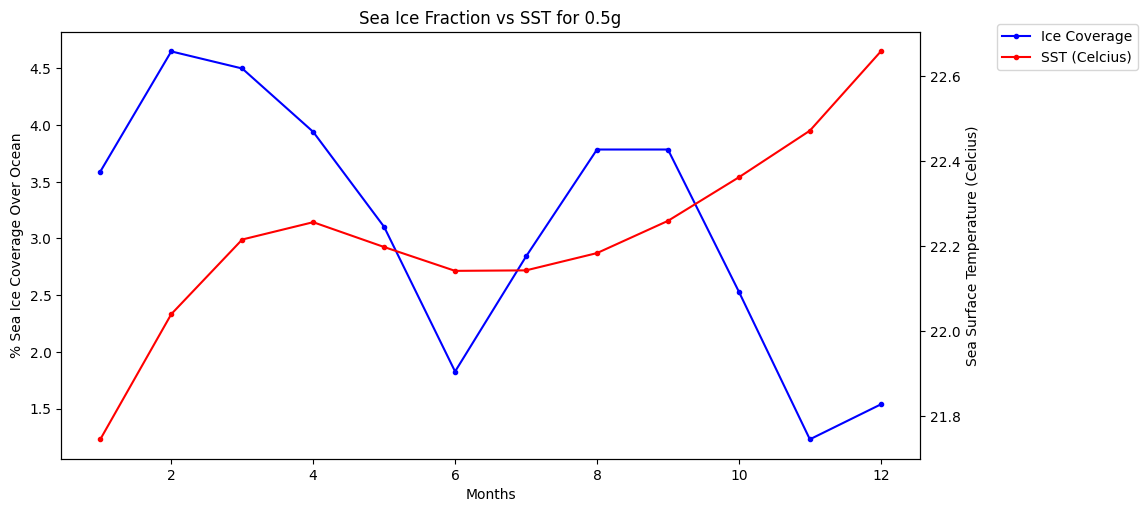

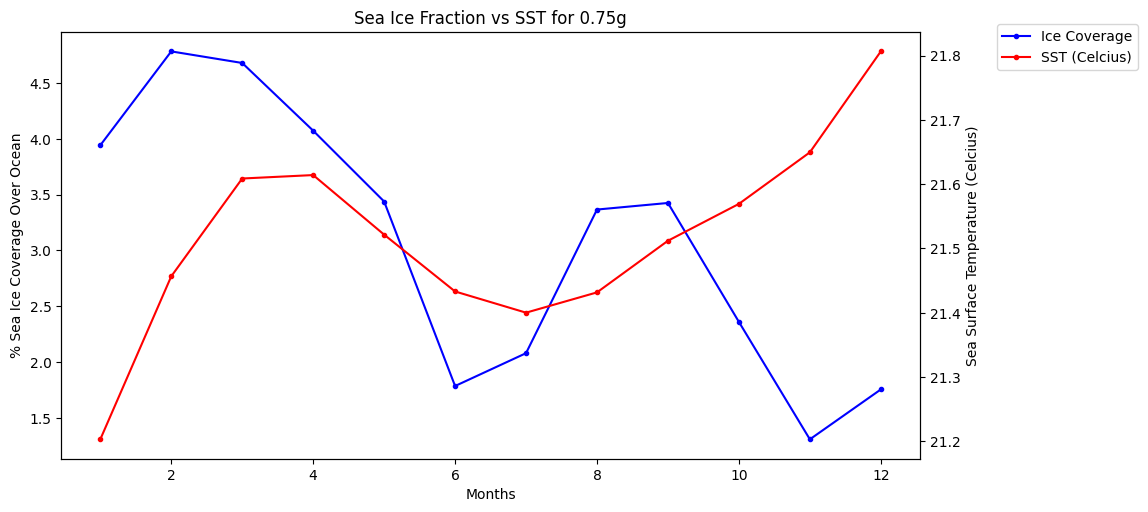

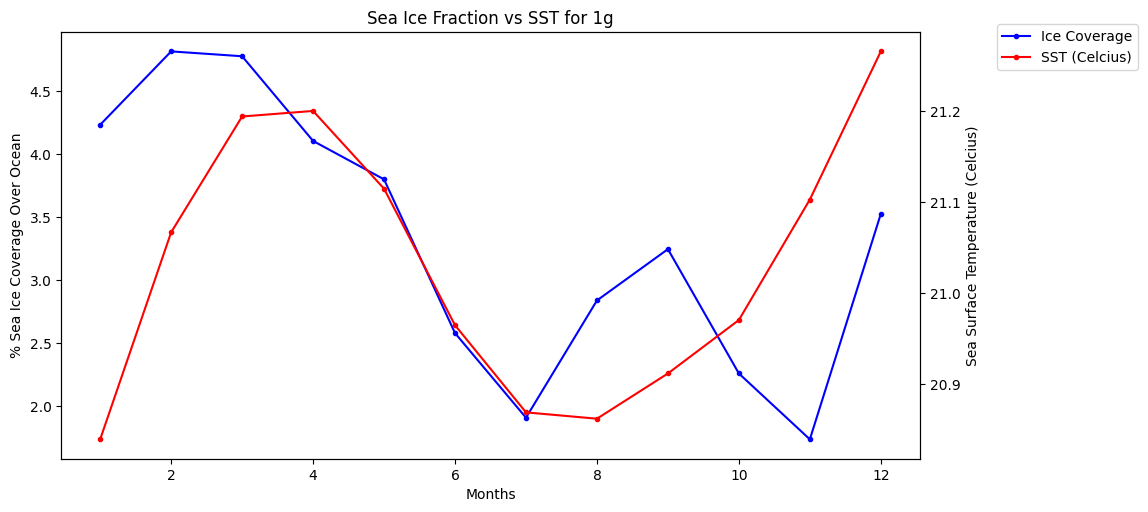

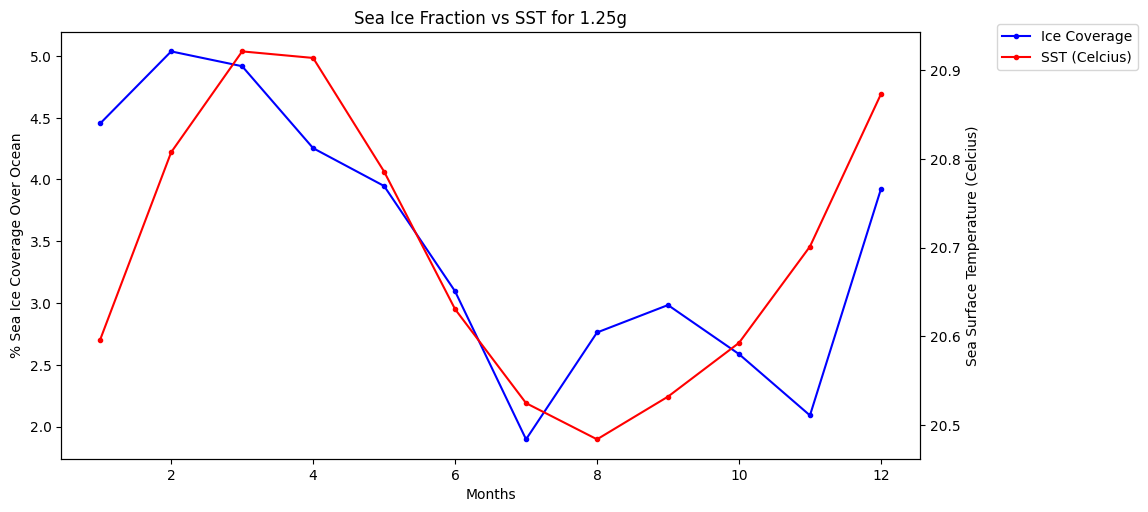

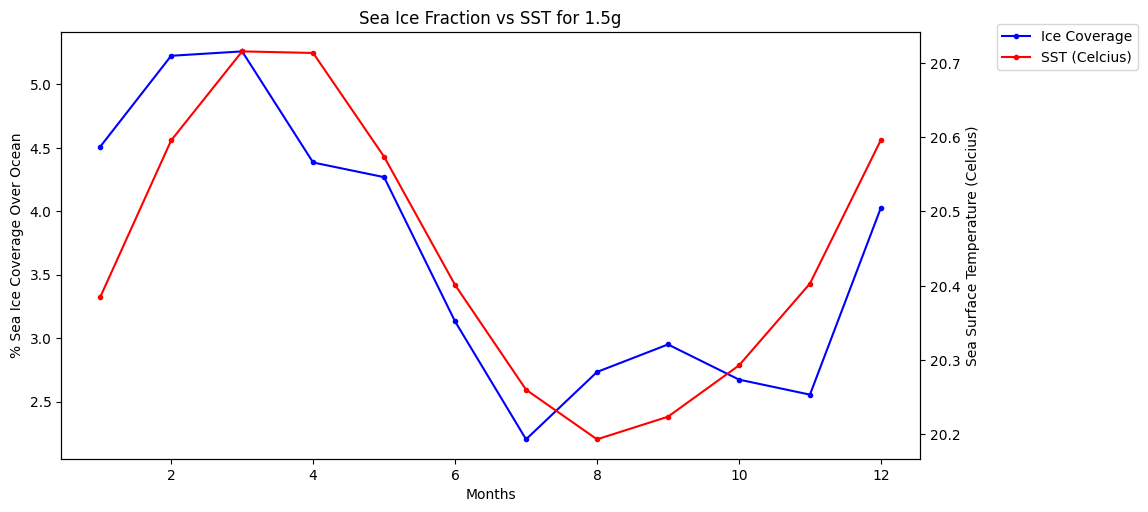

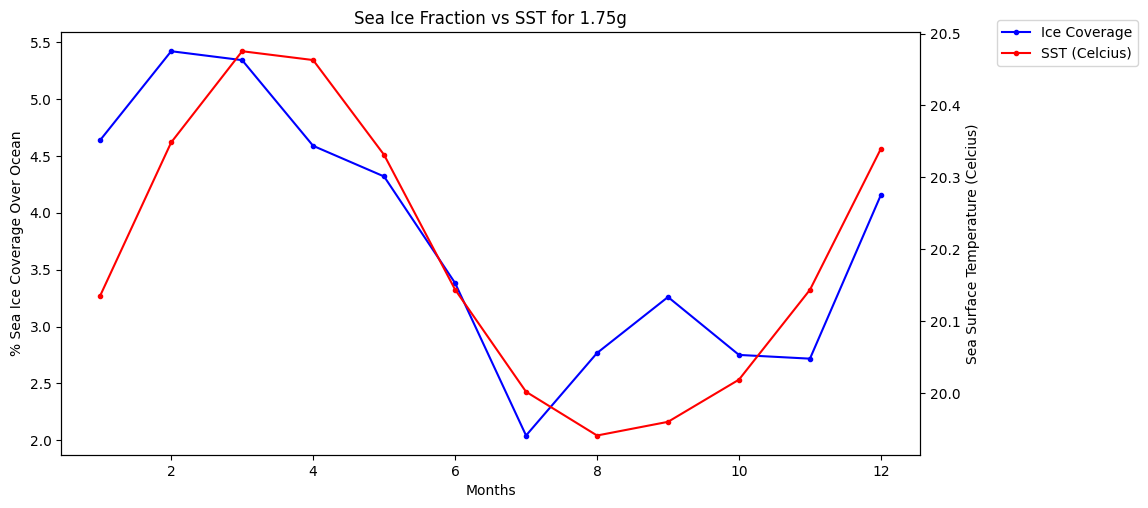

In [8]:
for r, grav in zip(results, gravity):
    sst = r["data"]["sst_tot"]
    sic = r["data"]["ice_tot"]
    month = r["data"]["month"][0]

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # First y-axis
    ax1.plot(month, sic, marker='.', color='blue', label="Ice Coverage")
    ax1.set_xlabel("Months")
    ax1.set_ylabel("% Sea Ice Coverage Over Ocean")

    # Second y-axis (shares the same x-axis)
    ax2 = ax1.twinx()
    ax2.plot(month, sst, marker='.', color='red', label="SST (Celcius)")
    ax2.set_ylabel("Sea Surface Temperature (Celcius)")

    fig.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
    plt.tight_layout()
    # plt.title(f"Sea Ice Fraction vs SST for {axtilt}$^o$")
    # plt.title(f"Sea Ice Fraction vs SST for {grav}g")
    plt.title(f"Sea Ice Fraction vs SST for {grav}g")
    plt.show()

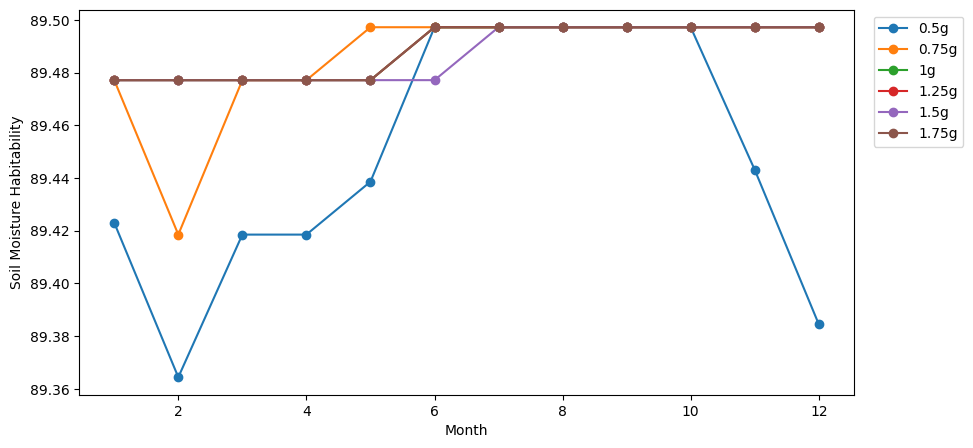

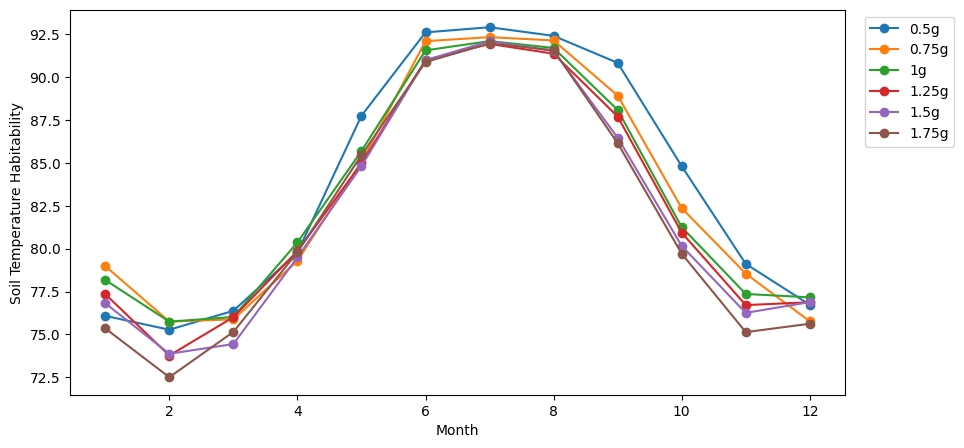

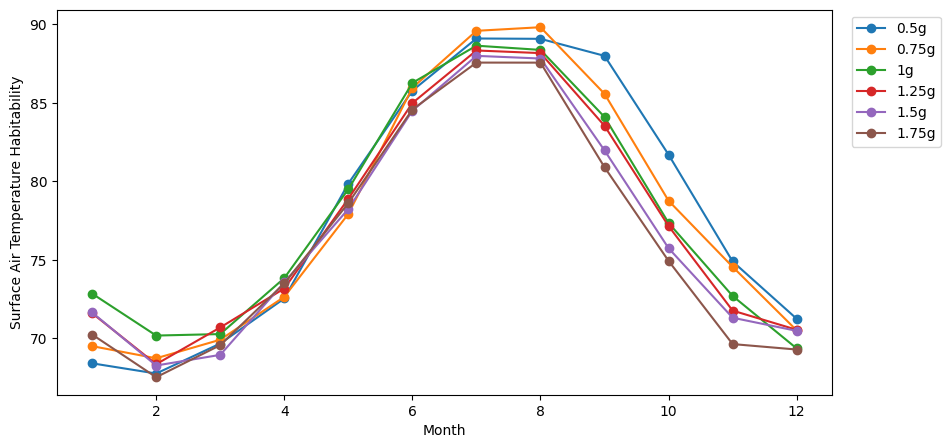

In [10]:
fig = plt.figure(figsize=(10, 5))
for r, grav in zip(results, gravity):
    sm = r["data"]["sm_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, sm, marker='o', label=f"{grav}g")
plt.xlabel("Month")
plt.ylabel("Soil Moisture Habitability")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, grav in zip(results, gravity):
    st = r["data"]["st_tot"]
    month = r["data"]["month"][0]
    # plt.plot(month, st, marker='o', label=f"{axtilt}$^o$")
    # plt.plot(month, st, marker='o', label=f"{grav}g")
    plt.plot(month, st, marker='o', label=f"{grav}g")
plt.xlabel("Month")
plt.ylabel("Soil Temperature Habitability")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, grav in zip(results, gravity):
    st = r["data"]["tsurf_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, st, marker='o', label=f"{grav}g")
plt.xlabel("Month")
plt.ylabel("Surface Air Temperature Habitability")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

/var/folders/_z/12jwk5k94hvctprv3dvrm2_c0000gp/T/ipykernel_93968/2242447603.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))


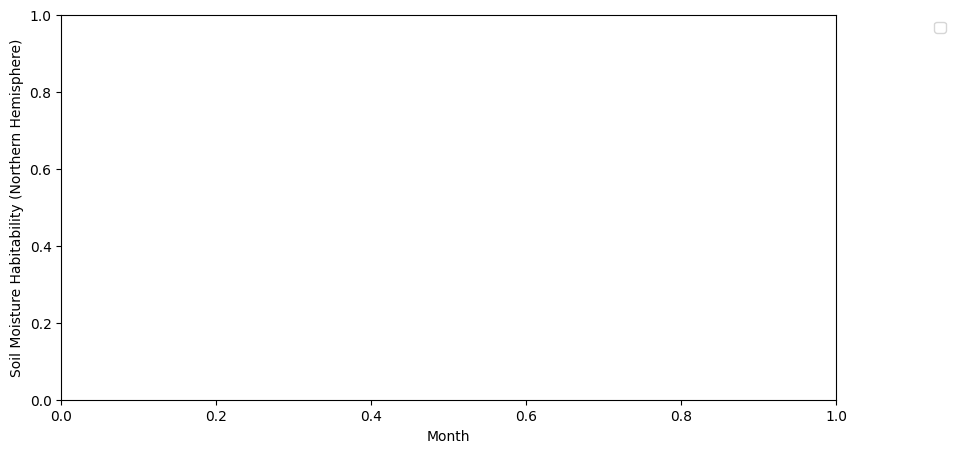

/var/folders/_z/12jwk5k94hvctprv3dvrm2_c0000gp/T/ipykernel_93968/2242447603.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))


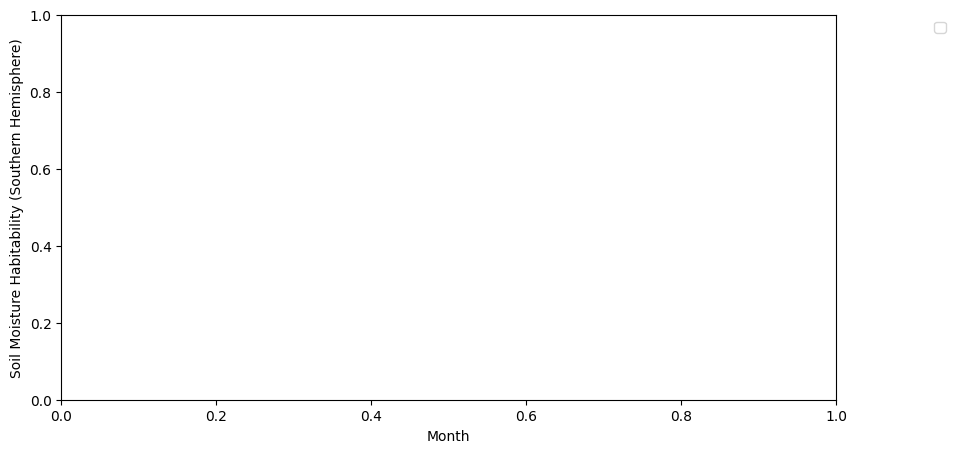

In [52]:
# Check habitability in different hemispheres for soil moisture 

fig = plt.figure(figsize=(10, 5))
for r in results[0:9]:
    # axtilt = at[results.index(r)]
    grav = gravity[results.index(r)]
    sm = r["data"]["sm_nhem"]
    month = r["data"]["month"][0]
    # plt.plot(month, sm, marker='o', label=f"{axtilt}$^o$")
    plt.plot(month, sm, marker='o', label=f"{grav}g")
plt.xlabel("Month")
plt.ylabel("Soil Moisture Habitability (Northern Hemisphere)")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r in results[0:9]:
    # axtilt = at[results.index(r)]
    grav = gravity[results.index(r)]
    sm = r["data"]["sm_shem"]
    month = r["data"]["month"][0]
    # plt.plot(month, sm, marker='o', label=f"{axtilt}$^o$")
    plt.plot(month, sm, marker='o', label=f"{grav}g")
plt.xlabel("Month")
plt.ylabel("Soil Moisture Habitability (Southern Hemisphere)")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

There is a turning point between 40 and 50 degrees in the habitability for temperature

Check north and south hemisphere to see if this is why

/var/folders/_z/12jwk5k94hvctprv3dvrm2_c0000gp/T/ipykernel_93968/2035670974.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))


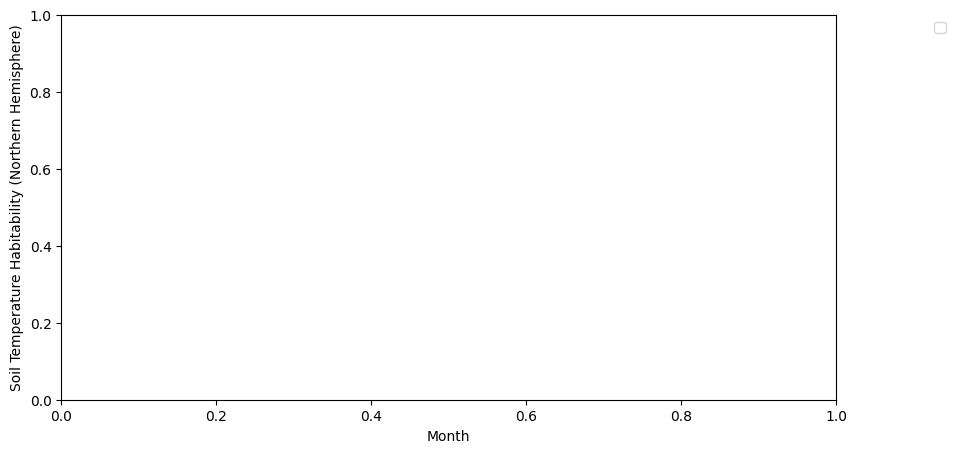

/var/folders/_z/12jwk5k94hvctprv3dvrm2_c0000gp/T/ipykernel_93968/2035670974.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))


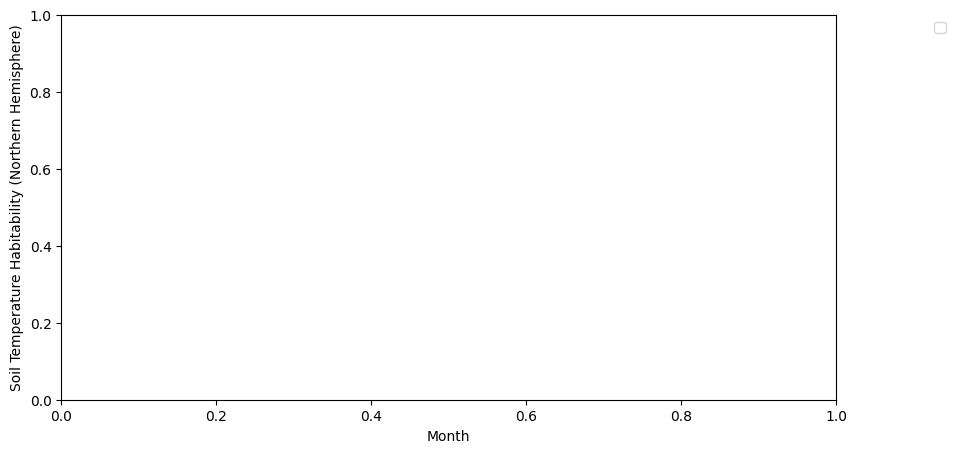

/var/folders/_z/12jwk5k94hvctprv3dvrm2_c0000gp/T/ipykernel_93968/2035670974.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))


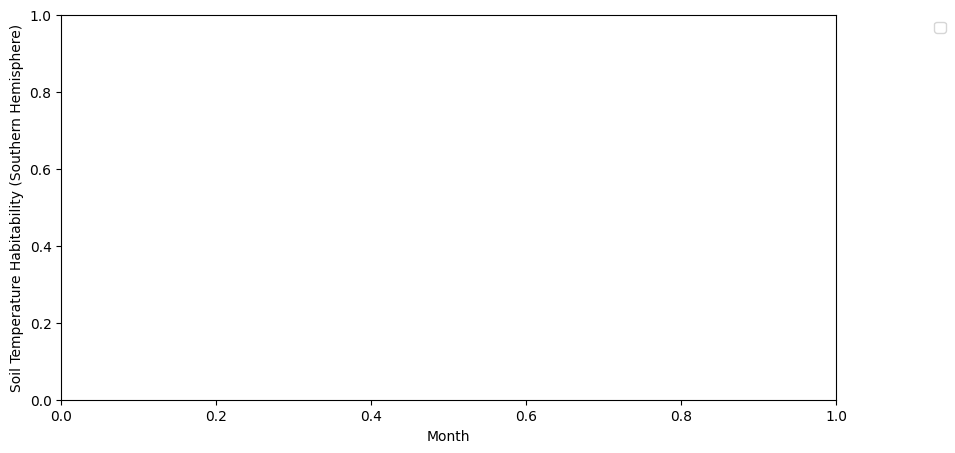

In [53]:
fig = plt.figure(figsize=(10, 5))
for r in results[0:5]:
    # axtilt = at[results.index(r)]
    grav = gravity[results.index(r)]
    st = r["data"]["st_nhem"]
    month = r["data"]["month"][0]
    # plt.plot(month, st, marker='o', label=f"{axtilt}$^o$")
    plt.plot(month, st, marker='o', label=f"{grav}g")
plt.xlabel("Month")
plt.ylabel("Soil Temperature Habitability (Northern Hemisphere)")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r in results[6:9]:
    # axtilt = at[results.index(r)]
    grav = gravity[results.index(r)]
    st = r["data"]["st_nhem"]
    month = r["data"]["month"][0]
    # plt.plot(month, st, marker='o', label=f"{axtilt}$^o$")
    plt.plot(month, st, marker='o', label=f"{grav}g")
plt.xlabel("Month")
plt.ylabel("Soil Temperature Habitability (Northern Hemisphere)")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r in results[0:9]:
    # axtilt = at[results.index(r)]
    grav = gravity[results.index(r)]
    st = r["data"]["st_shem"]
    month = r["data"]["month"][0]
    # plt.plot(month, st, marker='o', label=f"{axtilt}$^o$")
    plt.plot(month, st, marker='o', label=f"{grav}g")
plt.xlabel("Month")
plt.ylabel("Soil Temperature Habitability (Southern Hemisphere)")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

Hypothesis - temperature is too high in July to be habitable 

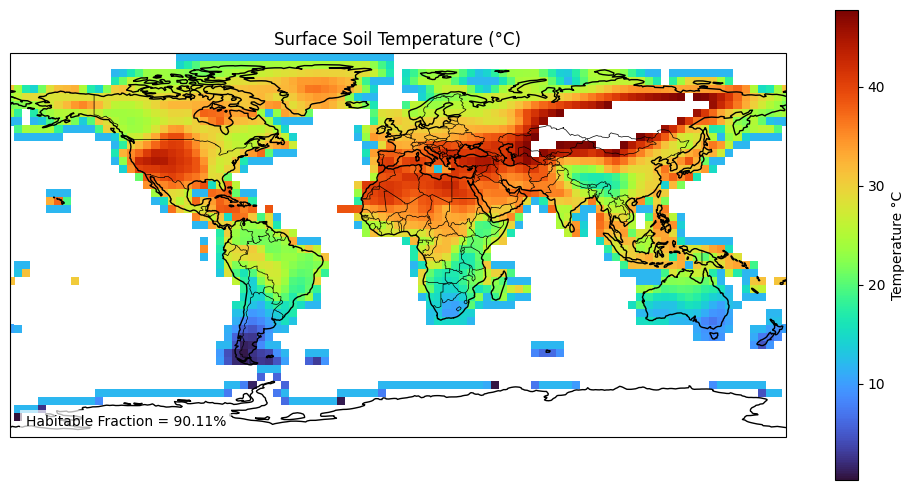

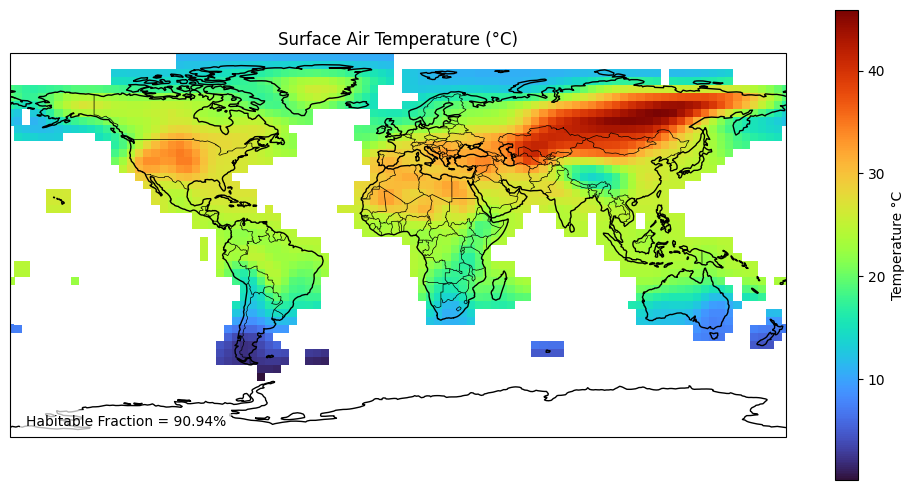

In [54]:
ds = xr.open_dataset("../axialtilt/output5.nc")
ds_crop = ds.sel(time=slice("2001-07-01", "2001-08-01"))

fraction_sm = Habitability.fraction(ds_crop, "sm")[0]
fraction_st = Habitability.fraction(ds_crop, "st")[0]
fraction_tsurf = Habitability.fraction(ds_crop, "tsurf")[0]

st = Habitability.fraction(ds_crop, "st")[1]
tsurf = Habitability.fraction(ds_crop, "tsurf")[1]
st_hab = Habitability.fraction(ds_crop, "st")[2]
tsurf_hab = Habitability.fraction(ds_crop, "tsurf")[2]

# Creating figures
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

st.where(st_hab).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "Temperature °C"},
    cmap="turbo"
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Surface Soil Temperature (°C)")

ax.text(0.02, 0.02, f"Habitable Fraction = {fraction_st:.2f}%",
    transform=ax.transAxes,
    ha="left", va="bottom",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)
plt.tight_layout()

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

tsurf.where(tsurf_hab).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "Temperature °C"},
    cmap="turbo"
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Surface Air Temperature (°C)")

ax.text(0.02, 0.02, f"Habitable Fraction = {fraction_tsurf:.2f}%",
    transform=ax.transAxes,
    ha="left", va="bottom",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)
plt.tight_layout()


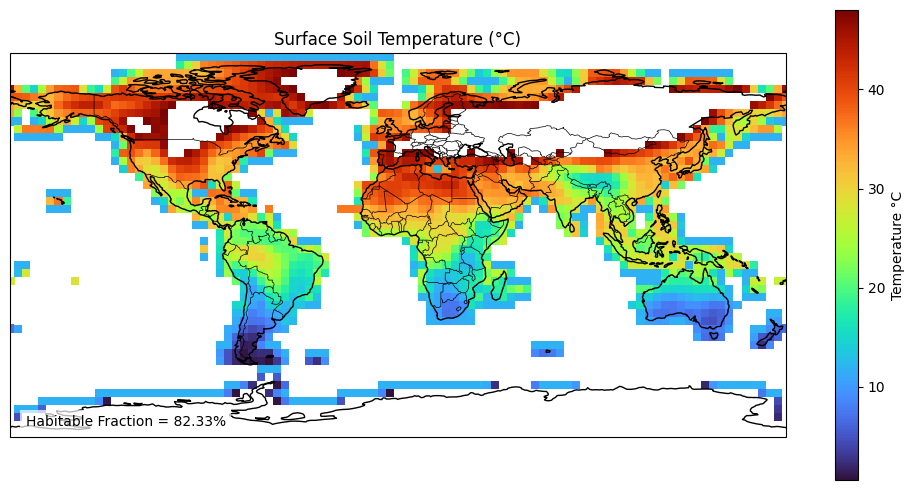

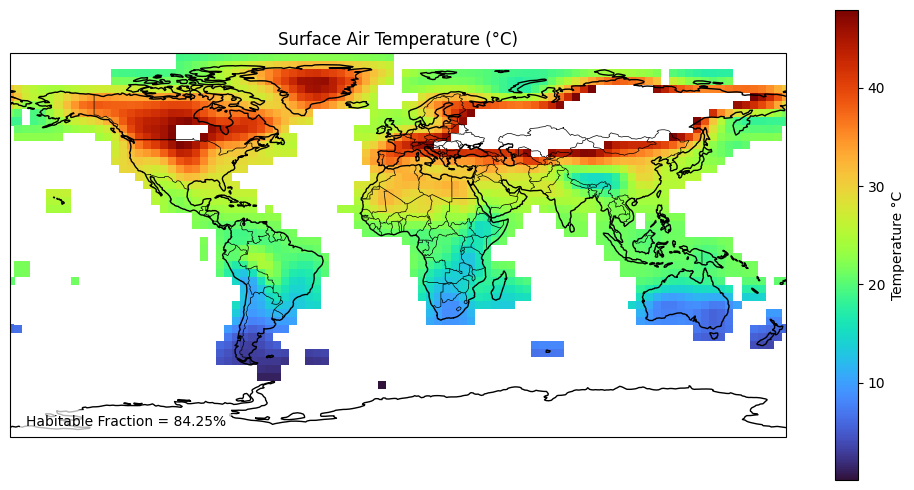

In [55]:
ds = xr.open_dataset("../axialtilt/output6.nc")
ds_crop = ds.sel(time=slice("2001-07-01", "2001-08-01"))

fraction_st = Habitability.fraction(ds_crop, "st")[0]
fraction_tsurf = Habitability.fraction(ds_crop, "tsurf")[0]

st = Habitability.fraction(ds_crop, "st")[1]
tsurf = Habitability.fraction(ds_crop, "tsurf")[1]
st_hab = Habitability.fraction(ds_crop, "st")[2]
tsurf_hab = Habitability.fraction(ds_crop, "tsurf")[2]

# Creating figures
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

st.where(st_hab).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "Temperature °C"},
    cmap="turbo"
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Surface Soil Temperature (°C)")

ax.text(0.02, 0.02, f"Habitable Fraction = {fraction_st:.2f}%",
    transform=ax.transAxes,
    ha="left", va="bottom",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)
plt.tight_layout()

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

tsurf.where(tsurf_hab).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "Temperature °C"},
    cmap="turbo"
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Surface Air Temperature (°C)")

ax.text(0.02, 0.02, f"Habitable Fraction = {fraction_tsurf:.2f}%",
    transform=ax.transAxes,
    ha="left", va="bottom",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)
plt.tight_layout()


We can see an increase in the temperature in the Northern hemisphere is causing regions to become uninhabitable, resulting in a decrease in habitability with increasing axial tilt.

Now we investigate the sea ice in the northern vs southern hemisphere to see how this varies

/var/folders/_z/12jwk5k94hvctprv3dvrm2_c0000gp/T/ipykernel_93968/2303954023.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))


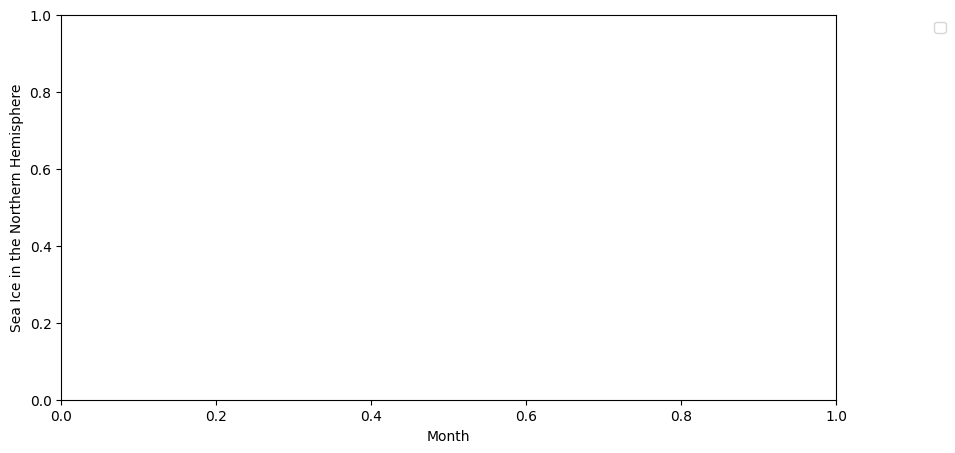

/var/folders/_z/12jwk5k94hvctprv3dvrm2_c0000gp/T/ipykernel_93968/2303954023.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))


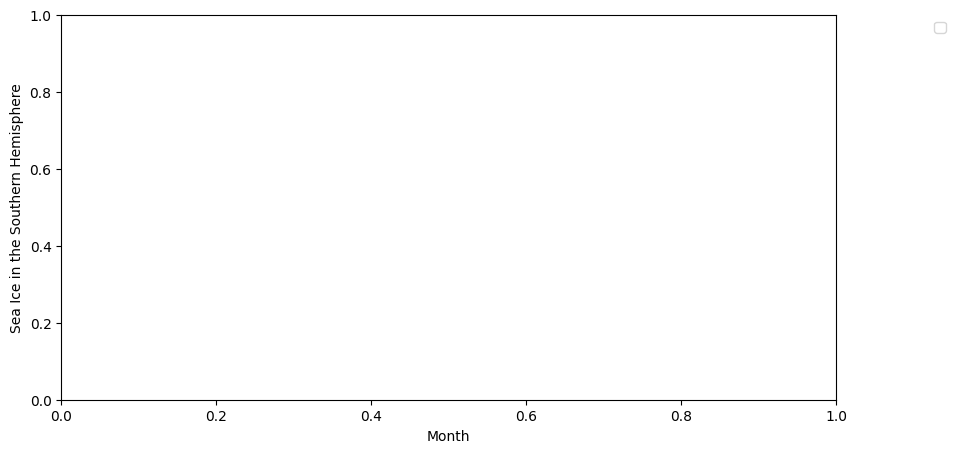

/var/folders/_z/12jwk5k94hvctprv3dvrm2_c0000gp/T/ipykernel_93968/2303954023.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))


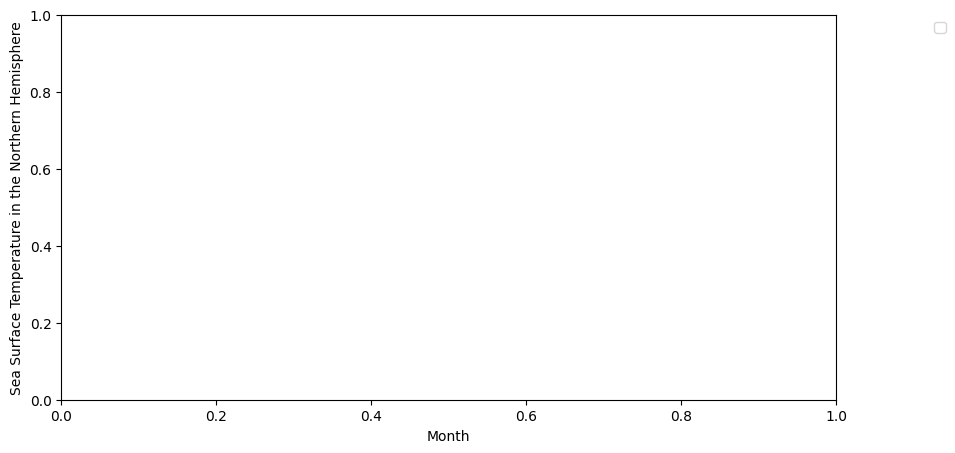

/var/folders/_z/12jwk5k94hvctprv3dvrm2_c0000gp/T/ipykernel_93968/2303954023.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))


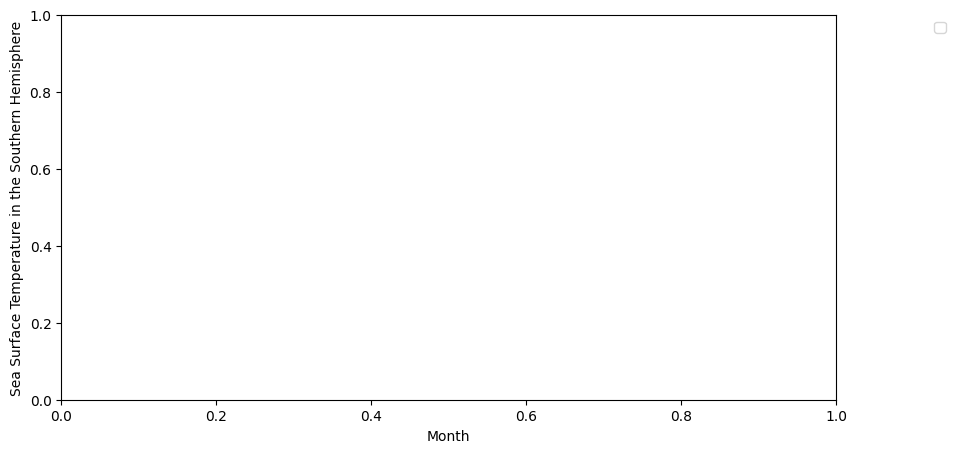

In [56]:
fig = plt.figure(figsize=(10, 5))
for r in results[0:9]:
    # axtilt = at[results.index(r)]
    grav = gravity[results.index(r)]
    st = r["data"]["ice_nhem"]
    month = r["data"]["month"][0]
    # plt.plot(month, st, marker='o', label=f"{axtilt}$^o$")
    plt.plot(month, st, marker='o', label=f"{grav}g")
plt.xlabel("Month")
plt.ylabel("Sea Ice in the Northern Hemisphere")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r in results[0:9]:
    # axtilt = at[results.index(r)]
    grav = gravity[results.index(r)]
    st = r["data"]["ice_shem"]
    month = r["data"]["month"][0]
    # plt.plot(month, st, marker='o', label=f"{axtilt}$^o$")
    plt.plot(month, st, marker='o', label=f"{grav}g")
plt.xlabel("Month")
plt.ylabel("Sea Ice in the Southern Hemisphere")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r in results[0:9]:
    # axtilt = at[results.index(r)]
    grav = gravity[results.index(r)]
    st = r["data"]["sst_nhem"]
    month = r["data"]["month"][0]
    # plt.plot(month, st, marker='o', label=f"{axtilt}$^o$")
    plt.plot(month, st, marker='o', label=f"{grav}g")
plt.xlabel("Month")
plt.ylabel("Sea Surface Temperature in the Northern Hemisphere")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r in results[0:9]:
    # axtilt = at[results.index(r)]
    grav = gravity[results.index(r)]
    st = r["data"]["sst_shem"]
    month = r["data"]["month"][0]
    # plt.plot(month, st, marker='o', label=f"{axtilt}$^o$")
    plt.plot(month, st, marker='o', label=f"{grav}g")
plt.xlabel("Month")
plt.ylabel("Sea Surface Temperature in the Southern Hemisphere")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

See if there's a correlation between incoming solar flux and sea ice conc/SST/habitability

/var/folders/_z/12jwk5k94hvctprv3dvrm2_c0000gp/T/ipykernel_93968/1351730827.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))


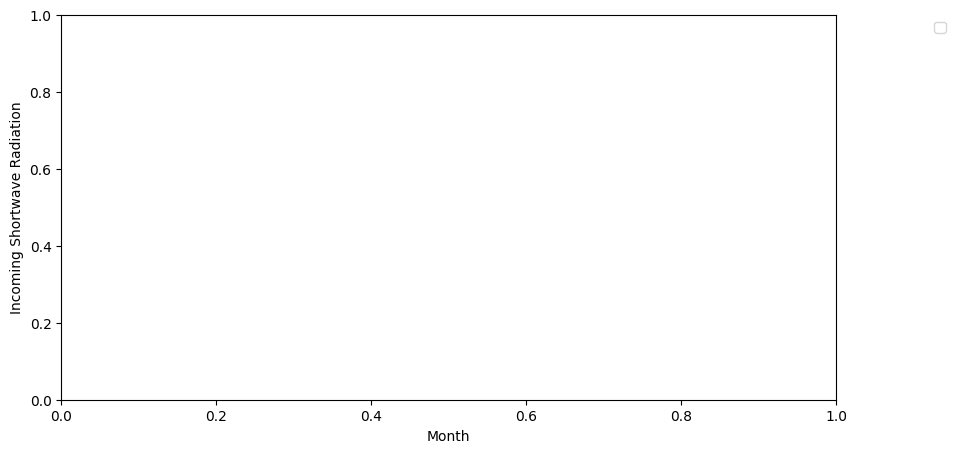

In [57]:
fig = plt.figure(figsize=(10, 5))
for r in results[0:9]:
    # axtilt = at[results.index(r)]
    grav = gravity[results.index(r)]
    srd = r["data"]["srd_tot"]
    month = r["data"]["month"][0]
    # plt.plot(month, srd, marker='o', label=f"{axtilt}$^o$")
    plt.plot(month, srd, marker='o', label=f"{grav}g")  
plt.xlabel("Month")
plt.ylabel(f"Incoming Shortwave Radiation")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

In [58]:
for r in results[0:9]:
    sst = r["data"]["sst_tot"]
    sic = r["data"]["ice_tot"]
    srd = r["data"]["srd_tot"]
    month = r["data"]["month"][0]
    # axtilt = at[results.index(r)]
    grav = gravity[results.index(r)]

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # First y-axis
    ax1.plot(month, sic, marker='.', color='blue', label="Ice Coverage")
    ax1.set_xlabel("Months")
    ax1.set_ylabel("% Sea Ice Coverage Over Ocean")

    # Second y-axis (shares the same x-axis)
    ax2 = ax1.twinx()
    ax2.plot(month, sst, marker='.', color='red', label="SST")
    ax2.set_ylabel("Sea Surface Temperature (Celcius)")

    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("axes", 1.2))
    ax3.plot(month, srd, marker='.', color='green', label="SRD")
    ax3.set_ylabel("Incoming Shortwave Radiation")

    fig.legend(loc="upper right", bbox_to_anchor=(0.9, 1))
    plt.tight_layout()
    # plt.title(f"Sea Ice, SST, and Shortwave Radiation for {axtilt}$^o$")
    plt.title(f"Sea Ice, SST, and Shortwave Radiation for {grav}g")
    plt.show()

In [59]:
for r in results[0:9]:
    # axtilt = at[results.index(r)]
    grav = gravity[results.index(r)]
    sst = r["data"]["sst_nhem"]
    sic = r["data"]["ice_nhem"]
    srd = r["data"]["srd_nhem"]
    month = r["data"]["month"][0]

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # First y-axis
    ax1.plot(month, sic, marker='.', color='blue', label="Ice Coverage")
    ax1.set_xlabel("Months")
    ax1.set_ylabel("% Sea Ice Coverage Over Ocean")

    # Second y-axis (shares the same x-axis)
    ax2 = ax1.twinx()
    ax2.plot(month, sst, marker='.', color='red', label="SST")
    ax2.set_ylabel("Sea Surface Temperature (Celcius)")

    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("axes", 1.2))
    ax3.plot(month, srd, marker='.', color='green', label="SRD")
    ax3.set_ylabel("Incoming Shortwave Radiation")

    fig.legend(loc="upper right", bbox_to_anchor=(0.9, 1))
    plt.tight_layout()
    # plt.title(f"Sea Ice, SST, and Shortwave Radiation in the Northern Hemisphere for {axtilt}$^o$")
    plt.title(f"Sea Ice, SST, and Shortwave Radiation in the Northern Hemisphere for {grav}g")
    plt.show()

In [60]:
for r in results[0:9]:
    # axtilt = at[results.index(r)] 
    grav = gravity[results.index(r)]  
    sst = r["data"]["sst_shem"]
    sic = r["data"]["ice_shem"]
    srd = r["data"]["srd_shem"]
    month = r["data"]["month"][0]

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # First y-axis
    ax1.plot(month, sic, marker='.', color='blue', label="Ice Coverage")
    ax1.set_xlabel("Months")
    ax1.set_ylabel("% Sea Ice Coverage Over Ocean")

    # Second y-axis (shares the same x-axis)
    ax2 = ax1.twinx()
    ax2.plot(month, sst, marker='.', color='red', label="SST")
    ax2.set_ylabel("SST")

    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("axes", 1.2))
    ax3.plot(month, srd, marker='.', color='green', label="SRD")
    ax3.set_ylabel("SRD")

    fig.legend(loc="upper right", bbox_to_anchor=(0.9, 1))
    plt.tight_layout()
    # plt.title(f"Sea Ice, SST, and Shortwave Radiation in the Southern Hemisphere for {axtilt}$^o$")
    plt.title(f"Sea Ice, SST, and Shortwave Radiation in the Southern Hemisphere for {grav}g")
    plt.show()

In [61]:
for r in results[0:9]:
    # axtilt = at[results.index(r)]
    grav = gravity[results.index(r)]
    st = r["data"]["st_tot"]
    tsurf = r["data"]["tsurf_tot"]
    sm = r["data"]["sm_tot"]
    srd = r["data"]["srd_tot"]
    month = r["data"]["month"][0]

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # First y-axis
    ax1.plot(month, sm, marker='.', color='blue', label="Soil Moisture")
    ax1.plot(month, st, marker='.', color='cyan', label="Soil Temperature")
    ax1.plot(month, tsurf, marker='.', color='navy', label="Surface Air Temperature")
    ax1.set_xlabel("Months")
    ax1.set_ylabel("Habitability")


    # Third y-axis (shares the same x-axis)
    ax2 = ax1.twinx()
    ax2.plot(month, srd, marker='.', color='red', label="Shortwave Radiation")
    ax2.set_ylabel("Shortwave Radiation")

    fig.legend(loc="upper right", bbox_to_anchor=(1.2, 1))
    plt.tight_layout()
    # plt.title(f"Habitability and Shortwave Radiation for {axtilt}$^o$ axial tilt")
    plt.title(f"Habitability and Shortwave Radiation for {grav}g")
    plt.show()

In [62]:
for r in results[0:9]:
    st = r["data"]["st_nhem"]
    tsurf = r["data"]["tsurf_nhem"]
    sm = r["data"]["sm_nhem"]
    srd = r["data"]["srd_nhem"]
    month = r["data"]["month"][0]
    grav = gravity[results.index(r)]

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # First y-axis
    ax1.plot(month, sm, marker='.', color='blue', label="Soil Moisture")
    ax1.plot(month, st, marker='.', color='cyan', label="Soil Temperature")
    ax1.plot(month, tsurf, marker='.', color='navy', label="Surface Air Temperature")
    ax1.set_xlabel("Months")
    ax1.set_ylabel("Soil Moisture")


    # Third y-axis (shares the same x-axis)
    ax2 = ax1.twinx()
    ax2.plot(month, srd, marker='.', color='red', label="Shortwave Radiation")
    ax2.set_ylabel("Shortwave Radiation")

    fig.legend(loc="upper right")
    plt.tight_layout()
    # plt.title("Habitability and Shortwave Radiation in the Northern Hemisphere for " + r["file"])
    plt.title(f"Habitability and Shortwave Radiation in the Northern Hemisphere for {grav}g")
    plt.show()

In [63]:
for r in results[0:9]:
    st = r["data"]["st_shem"]
    tsurf = r["data"]["tsurf_shem"]
    sm = r["data"]["sm_shem"]
    srd = r["data"]["srd_shem"]
    month = r["data"]["month"][0]
    grav = gravity[results.index(r)]

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # First y-axis
    ax1.plot(month, sm, marker='.', color='blue', label="Soil Moisture")
    ax1.plot(month, st, marker='.', color='cyan', label="Soil Temperature")
    ax1.plot(month, tsurf, marker='.', color='navy', label="Surface Air Temperature")
    ax1.set_xlabel("Months")
    ax1.set_ylabel("Soil Moisture")


    # Third y-axis (shares the same x-axis)
    ax2 = ax1.twinx()
    ax2.plot(month, srd, marker='.', color='red', label="Shortwave Radiation")
    ax2.set_ylabel("Shortwave Radiation")

    fig.legend(loc="upper right")
    plt.tight_layout()
    # plt.title("Habitability and Shortwave Radiation in the Southern Hemisphere for " + r["file"])
    plt.title(f"Habitability and Shortwave Radiation in the Southern Hemisphere for {grav}g")
    plt.show()